# Geospatial Data Processing Pipeline

## Table of Contents
1. [Abstract / Methodology Description](#abstract)
2. [Resumo / Metodologia (Portuguese)](#resumo)
3. [Setup and Imports](#setup)
4. [Apelos Processing](#apelos)
   - [KML to GeoJSON Conversion](#conversion)
   - [Data Cleaning](#cleaning)
5. [Neighborhood Survey](#survey)
   - [Neighborhood Filtering](#filtering)
   - [Map Visualization](#visualization)
   - [Data Export](#export)


### Abstract / Methodology Description <a name="abstract"></a>

**Overview of the Geospatial Processing Pipeline**
The map generation and spatial analysis were conducted in a Python environment utilizing a Jupyter Notebook. The workflow was divided into three main stages: data ingestion and cleaning, spatial operations integrating municipal data, and cartographic visualization. The final output of this pipeline was a series of detailed thematic maps illustrating the distribution of urban appeals (*apelos*) across the study area.

**1. Primary Data Ingestion and Cleaning**
The initial dataset of urban appeals (*apelos*), originally mapped in Google Earth as a KML file, was parsed and converted into a structured spatial format (GeoJSON) using a custom Python module (`geoprocess`). During the preprocessing phase, textual descriptions associated with each geographic point were cleaned. This involved executing custom string manipulation functions to strip raw HTML tags and extract relevant hyperlinks, ensuring the attribute table contained clean, standardized text.

**2. Spatial Analysis and Integration with Municipal Data (DATA.RIO)**
To provide an accurate urban context, official municipal geospatial datasets were imported from **DATA.RIO** (the open data portal of the Rio de Janeiro City Hall):
* **Neighborhood Boundaries (*Limite de Bairros*):** Used to identify and isolate the specific administrative neighborhoods that encompassed the mapped appeals.
* **City Blocks (*Quadras - 2013*):** Used to represent the granular urban fabric within the study area.

Spatial operations were performed extensively using the Python open-source library **GeoPandas**. The process included:
* **Spatial Intersection:** Using topological predicates (specifically, the `contains` method), the script iterated over the point data to identify the target neighborhoods.
* **Buffering and Contextualization:** A spatial union (`unary_union`) of the selected neighborhoods was created. A topological `touches` operation was then applied to the municipal neighborhood grid to extract the immediately surrounding neighborhoods, forming the "entorno" (surroundings).
* **Granular Urban Clipping:** The official DATA.RIO city blocks dataset was filtered using a spatial join (`gpd.sjoin`) and clipping (`gpd.clip`) to retain only the urban blocks situated strictly within the boundaries of the primary study area.

**3. Cartographic Visualization and Map Generation**
The final thematic maps were programmatically generated using **Matplotlib**, a comprehensive library for creating static visualizations in Python. The resulting maps provided a clear spatial narrative of the study area around Avenida Presidente Vargas.
* **Layering System:** The maps were built using a strict layer hierarchy: surrounding neighborhoods (context), target neighborhoods (focus), city blocks from DATA.RIO (urban fabric), and finally, the occurrences/appeals (*apelos*).
* **Geometric Differentiation:** The geospatial data was programmatically split into point geometries (isolated occurrences) and line geometries (e.g., Street Alignment Projects). 
* **Custom Symbology and Legends:** A sophisticated, custom legend was built to map specific hex color codes to categorical classifications (e.g., *Apelos Individuais* vs. Collective Appeals such as Banks, Churches, and Commercial Associations).
* **Labeling and Extent:** Neighborhood names were automatically placed at the geometric centroids of the polygons. Finally, the maps' viewports were strictly defined using specific bounding box coordinates (longitude and latitude limits) to frame the exact extent of the study area.

**Credits / Tools & Data Sources:**
* **Python** (Programming Language)
* **GeoPandas & Shapely** (for spatial data manipulation, spatial joins, and topological operations)
* **Matplotlib** (for cartographic plotting, layering, and custom legend generation)
* **DATA.RIO** (Prefeitura do Rio de Janeiro - source for the *Limite de Bairros* and *Quadras* geospatial datasets)
* **Jupyter Notebooks** (as the interactive development environment)


### Resumo / Metodologia <a name="resumo"></a>

**Visão Geral do Pipeline de Processamento Geoespacial**
A geração de mapas e a análise espacial foram conduzidas em um ambiente Python utilizando um Jupyter Notebook. O fluxo de trabalho foi dividido em três etapas principais: ingestão e limpeza de dados, operações espaciais integrando dados municipais e visualização cartográfica. O resultado final deste pipeline foi uma série de mapas temáticos detalhados que ilustram a distribuição dos apelos urbanos em toda a área de estudo.

**1. Ingestão Primária e Limpeza de Dados**
O conjunto de dados inicial de apelos urbanos, mapeado originalmente no Google Earth como um arquivo KML, foi analisado e convertido em um formato espacial estruturado (GeoJSON) usando um módulo Python customizado (`geoprocess`). Durante a fase de pré-processamento, as descrições em texto associadas a cada ponto geográfico foram limpas. Isso envolveu a execução de funções personalizadas de manipulação de strings para remover tags HTML brutas e extrair hiperlinks relevantes, garantindo que a tabela de atributos contivesse textos padronizados e limpos.

**2. Análise Espacial e Integração com Dados Municipais (DATA.RIO)**
Para fornecer um contexto urbano preciso, conjuntos de dados geoespaciais oficiais do município foram importados do **DATA.RIO** (o portal de dados abertos da Prefeitura do Rio de Janeiro):
* **Limites de Bairros:** Utilizados para identificar e isolar os bairros administrativos específicos que englobavam os apelos mapeados.
* **Quadras (2013):** Utilizadas para representar a malha urbana granular dentro da área de estudo.

As operações espaciais foram realizadas extensivamente usando a biblioteca de código aberto em Python **GeoPandas**. O processo incluiu:
* **Interseção Espacial:** Usando predicados topológicos (especificamente, o método `contains`), o script iterou sobre os dados de pontos para identificar os bairros alvo.
* **Bufferização e Contextualização:** Foi criada uma união espacial (`unary_union`) dos bairros selecionados. Em seguida, uma operação topológica de toque (`touches`) foi aplicada à grade de bairros municipais para extrair os bairros imediatamente adjacentes, formando o "entorno".
* **Recorte Urbano Granular:** O conjunto de dados oficial de quadras do DATA.RIO foi filtrado usando uma união espacial (`gpd.sjoin`) e um recorte (`gpd.clip`) para manter apenas as quadras urbanas situadas estritamente dentro dos limites da área de estudo principal.

**3. Visualização Cartográfica e Geração de Mapas**
Os mapas temáticos finais foram gerados de forma programática usando **Matplotlib**, uma biblioteca abrangente para criação de visualizações estáticas em Python. Os mapas resultantes forneceram uma narrativa espacial clara da área de estudo ao redor da Avenida Presidente Vargas.
* **Sistema de Camadas:** Os mapas foram construídos usando uma hierarquia de camadas estrita: bairros do entorno (contexto), bairros alvo (foco), quadras do DATA.RIO (malha urbana) e, finalmente, as ocorrências/apelos (*apelos*).
* **Diferenciação Geométrica:** Os dados geoespaciais foram divididos programaticamente em geometrias de pontos (ocorrências isoladas) e geometrias de linhas (ex.: Projetos de Alinhamento).
* **Simbologia Personalizada e Legendas:** Uma legenda sofisticada e customizada foi construída para mapear códigos de cores hexadecimais específicos para classificações categóricas (ex.: *Apelos Individuais* vs. Apelos Coletivos como Bancos, Igrejas e Associações Comerciais).
* **Rotulagem e Extensão:** Os nomes dos bairros foram posicionados automaticamente nos centroides geométricos dos polígonos. Finalmente, as janelas de visualização (viewports) dos mapas foram estritamente definidas usando coordenadas específicas (limites de longitude e latitude) para enquadrar a extensão exata da área de estudo.

**Créditos / Ferramentas e Fontes de Dados:**
* **Python** (Linguagem de Programação)
* **GeoPandas & Shapely** (para manipulação de dados espaciais, uniões espaciais e operações topológicas)
* **Matplotlib** (para plotagem cartográfica, uso de camadas e geração de legendas customizadas)
* **DATA.RIO** (Prefeitura do Rio de Janeiro - fonte dos conjuntos de dados geoespaciais *Limite de Bairros* e *Quadras*)
* **Jupyter Notebooks** (como ambiente de desenvolvimento interativo)


## Setup and Imports <a name="setup"></a>


In [109]:
import matplotlib.pyplot as plt
import geopandas as gpd
import geoprocess as geo
geo.__version__

'0.1.0'

## Apelos Processing <a name="apelos"></a>

### KML to GeoJSON Conversion <a name="conversion"></a>

In [110]:
path_apelos = "raw_data/Presidente Vargas - mapeamento dos apelos p_ Cris.kml"
apelos = geo.convert_kml_to_geojson(
    path_apelos,
    "pre-processed_data/apelos_pres_vargas.geojson"
)

✅ Success! Converted 'raw_data/Presidente Vargas - mapeamento dos apelos p_ Cris.kml' to 'pre-processed_data/apelos_pres_vargas.geojson'


In [111]:
apelos.tail()

,Name,Description,geometry,Color
152,"R. Miguel Couto, 95","<div>G. Ricardo Dias - Rua Miguel Couto, 95<br...",POINT Z (-43.18026 -22.90126 5.29661),303f9f
153,"R. São Pedro, 86",<div>Armando Busseti &amp; Cia. - Rua São Pedr...,POINT Z (-43.17969 -22.90111 6.58031),303f9f
154,"Av. Presidente Vargas, 132",<div>Vitalino Ferreira da Costa - Av. Presiden...,POINT Z (-43.17753 -22.90041 6.42475),303f9f
155,PA3481,,"POLYGON Z ((-43.18766 -22.90524 0, -43.18528 -...",1976d2
156,PA3653,,"POLYGON Z ((-43.19119 -22.90419 0, -43.19502 -...",1976d2



### Data cleaning and exporting
 
In this step, we process the raw "apelos" data to clean up the text descriptions and extract any associated links. 
For each record, we:
1. Use `geo.get_first_url` to extract the first URL from the HTML description, storing it in a new 'Link' column.
2. Use `geo.get_clean_text` to remove HTML tags and links from the 'Description' field, leaving only the visible text.

After cleaning, we export the resulting GeoDataFrame to a new GeoJSON file for further analysis.

In [112]:
for idx, row in apelos.iterrows():
    link = geo.get_first_url(row['Description'])
    clean_desc = geo.get_clean_text(row['Description'])
    apelos.at[idx, 'Link'] = link
    apelos.at[idx, 'Description'] = clean_desc

# Export the processed GeoDataFrame to GeoJSON
geo.save_geojson_pretty(apelos, "processed_data/apelos_pres_vargas_clean.geojson");

✅ Success! Saved pretty GeoJSON to 'processed_data/apelos_pres_vargas_clean.geojson'


## Neighborhood Survey <a name="survey"></a>

### Data loading

In [113]:
# Reading the GeoJSON file with all the neighborhoods
gdf = gpd.read_file("DATA.RIO/Limite_de_Bairros.geojson")

# Reading the GeoJSON file with all the neighborhoods blocks
gdf_blocks = gpd.read_file("DATA.RIO/Quadras_(2013).geojson")

# Check the coordinate reference system
print(gdf.crs)
print(gdf_blocks.crs)

EPSG:4326
EPSG:4326


### Extraction n Filtering the neighborhoods ("bairros") and blocks (quadras) that contain at least one "apelo"

In [114]:
# Create a set to store the names of neighborhoods ("bairros") that contain at least one "apelo" point
bairros = set()

# For each point in the "apelos" GeoDataFrame
for point in apelos.geometry:
    # Iterate through each row (neighborhood) in the neighborhoods GeoDataFrame
    for idx, row in gdf.iterrows():
        # Check if the neighborhood geometry contains the current point
        if row['geometry'].contains(point):
            # If so, add the neighborhood name to the set and stop checking further neighborhoods for this point
            bairros.add(row['nome'])
            break

# Convert the set of neighborhood names to a list
bairros = list(bairros)

# Filter the neighborhoods GeoDataFrame to only those whose names are in the list of bairros containing apelos
filtro_bairros = gdf[gdf["nome"].isin(bairros)]

filtro_bairros["nome"]


89          Centro
101    Cidade Nova
Name: nome, dtype: object

In [115]:
filtro_quadras = gpd.sjoin(
    gdf_blocks, 
    filtro_bairros, 
    how="inner", 
    predicate="intersects" # "instesects" or "within" if you only want blocks fully contained inside the bairro
)

In [116]:
filtro_quadras = gpd.clip(gdf_blocks, filtro_bairros)

In [117]:
# 1. Combine all selected neighborhoods into a single larger geometry area
selected_area = filtro_bairros.geometry.unary_union

# 2. Find all neighborhoods in the original 'gdf' that touch the selected area
# Note: Use .intersects() instead of .touches() if your map's polygons slightly overlap rather than perfectly touching
touches_mask = gdf.geometry.touches(selected_area)

# 3. Get the GeoDataFrame of these touching neighborhoods
touching_bairros_gdf = gdf[touches_mask]

# 4. Create a set of their names, making sure to subtract the ones we already selected initially
surrounding_bairros = set(touching_bairros_gdf["nome"]) - set(bairros)

# 5. Filter the original gdf to create a new GeoDataFrame with just the surrounding neighborhoods
filtro_surrounding = gdf[gdf["nome"].isin(surrounding_bairros)]

# View the names of the surrounding neighborhoods
filtro_surrounding["nome"]

/var/folders/mr/k3m0b17x6h7bvhz8rdngny_h0000gn/T/ipykernel_10038/2939295781.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  selected_area = filtro_bairros.geometry.unary_union


87                Gamboa
88          Santo Cristo
92                 Saúde
102    Praça da Bandeira
105               Glória
107         Santa Teresa
108              Estácio
110              Catumbi
151                 Lapa
Name: nome, dtype: object

### Map Visualization <a name="visualization"></a>

/var/folders/mr/k3m0b17x6h7bvhz8rdngny_h0000gn/T/ipykernel_10038/608070203.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Cores', bbox_to_anchor=(1.05, 1), loc='upper left')


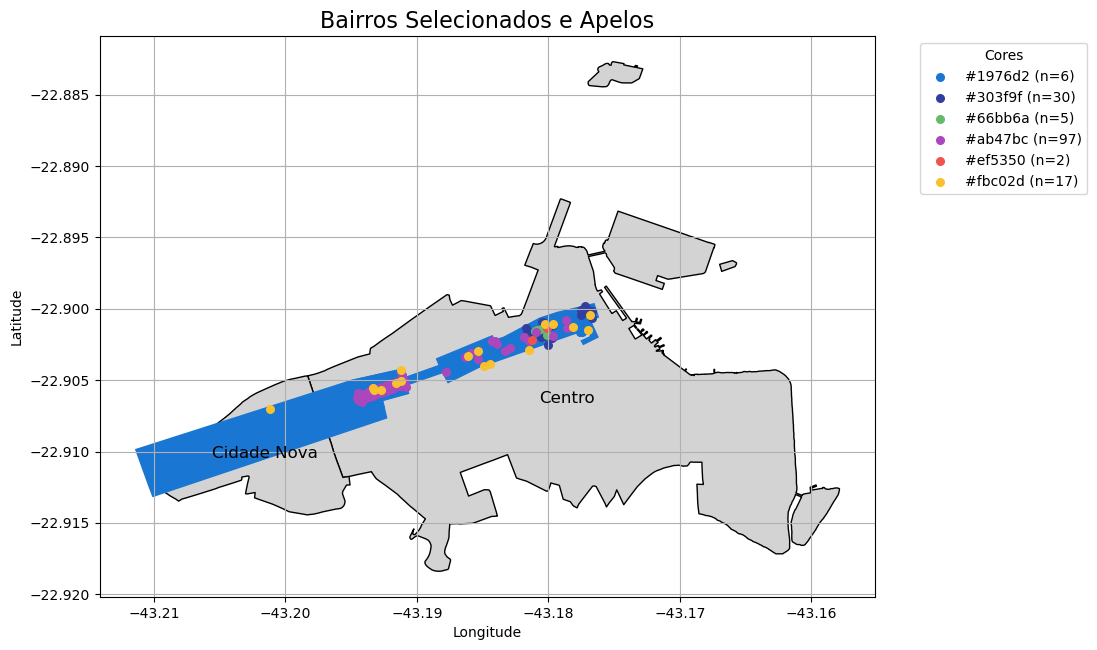

In [118]:
# Create a plot showing selected neighborhoods (filtro_bairros) and apelos
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot selected neighborhoods with a light gray color
filtro_bairros.plot(ax=ax, color='lightgray', edgecolor='black', legend=True)

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=12, ha='center', va='center')

# Plot apelos points, grouped by color to show the count in the legend
for color, group in apelos.groupby('Color'):
    count = len(group)
    # Plot each individual point of this color group
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', label=f'#{color} (n={count})')

# Customize the plot
ax.set_title("Bairros Selecionados e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title='Cores', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)

/var/folders/mr/k3m0b17x6h7bvhz8rdngny_h0000gn/T/ipykernel_10038/1913853347.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Cores', bbox_to_anchor=(1.05, 1), loc='upper left')


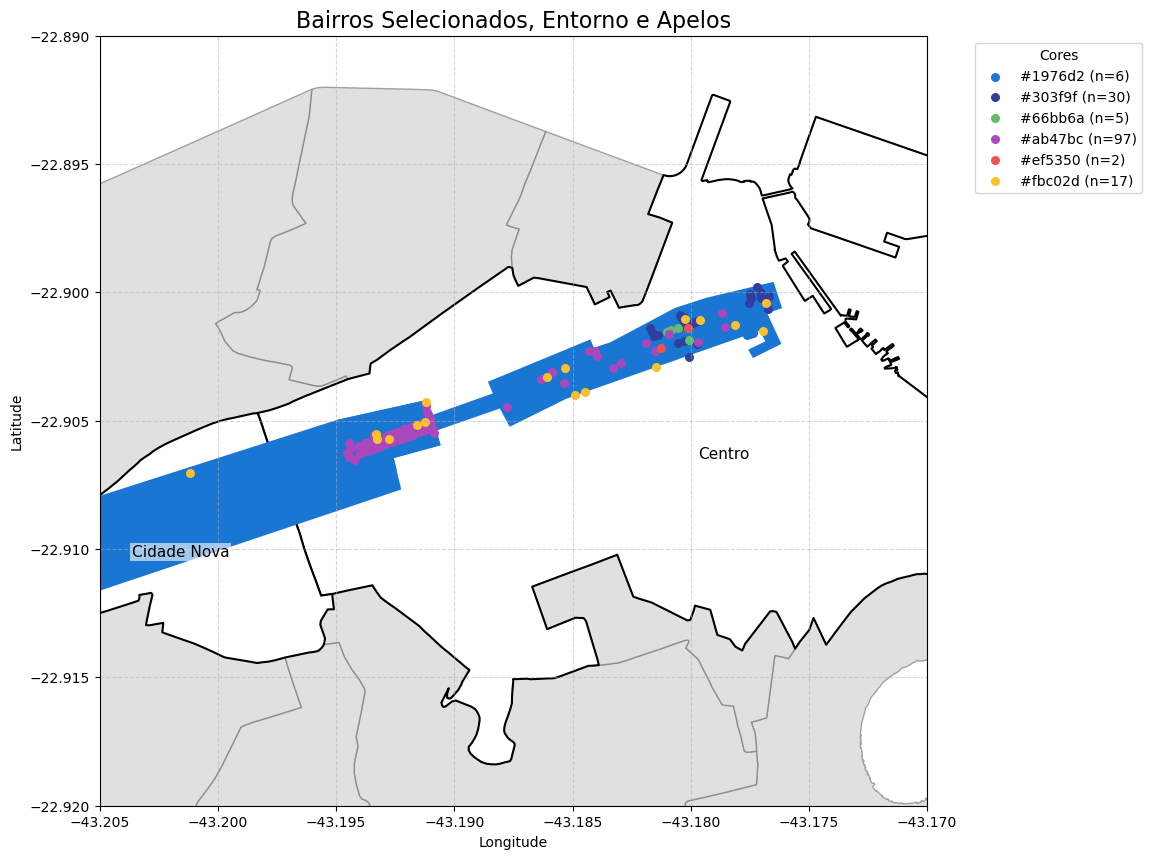

In [119]:
# Create a plot showing selected neighborhoods, surrounding neighborhoods, and apelos
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1. Plot surrounding neighborhoods in light gray
filtro_surrounding.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.7, label='Entorno')

# 2. Plot selected neighborhoods with a white background so they stand out
filtro_bairros.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, legend=True)

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=11, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Plot apelos points, grouped by color
for color, group in apelos.groupby('Color'):
    count = len(group)
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', label=f'#{color} (n={count})')

# Customize the plot
ax.set_title("Bairros Selecionados, Entorno e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ==========================================
# MANUALLY DEFINE X AND Y RANGE (LIMITS)
# ==========================================
# Replace these values with your desired bounding box coordinates
ax.set_xlim([-43.205, -43.17])  # [min_longitude, max_longitude]
ax.set_ylim([-22.92, -22.89])  # [min_latitude, max_latitude]

ax.legend(title='Cores', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

/var/folders/mr/k3m0b17x6h7bvhz8rdngny_h0000gn/T/ipykernel_10038/3305673711.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Cores', loc='upper left', framealpha=1.0)


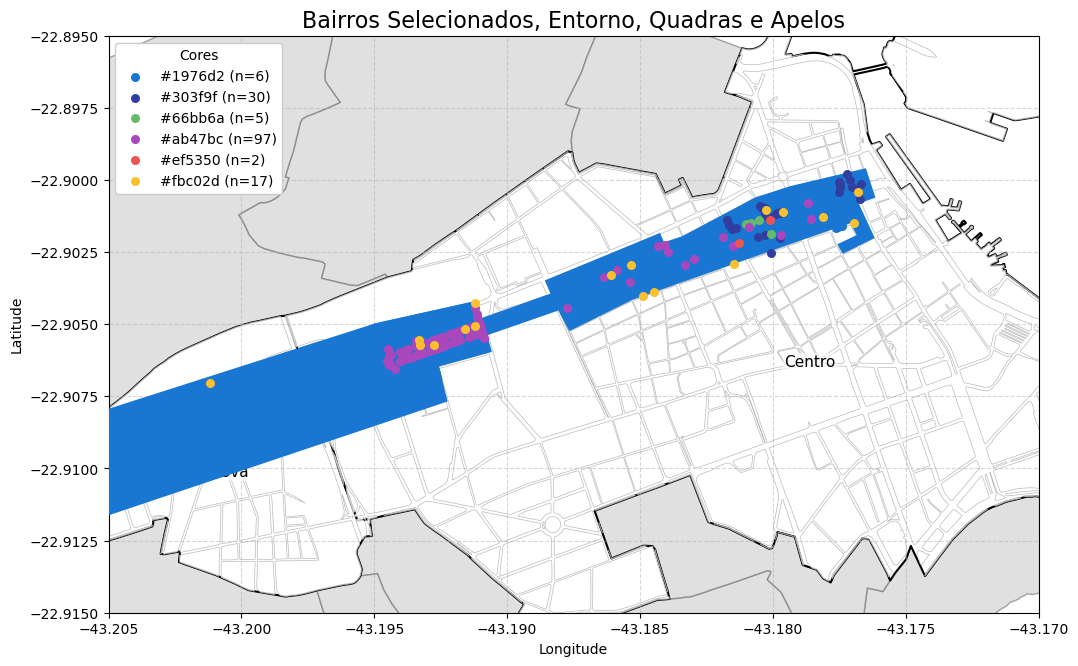

In [120]:
# Create a plot showing selected neighborhoods, surrounding neighborhoods, and apelos
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1. Plot surrounding neighborhoods in light gray
filtro_surrounding.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.7, label='Entorno')

# 2. Plot selected neighborhoods with a white background so they stand out
filtro_bairros.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, legend=True)

# 3. Plot the filtered blocks (quadras) in light gray
filtro_quadras.plot(ax=ax, color='white', edgecolor='darkgray', alpha=0.8, linewidth=0.5, label='Quadras')

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=11, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=4)

# Plot apelos points, grouped by color
for color, group in apelos.groupby('Color'):
    count = len(group)
    # Added zorder=5 to ensure points are always drawn on top of the blocks
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', label=f'#{color} (n={count})', zorder=5)

# Customize the plot
ax.set_title("Bairros Selecionados, Entorno, Quadras e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ==========================================
# MANUALLY DEFINE X AND Y RANGE (LIMITS)
# ==========================================
# Replace these values with your desired bounding box coordinates
ax.set_xlim([-43.205, -43.17])  # [min_longitude, max_longitude]
ax.set_ylim([-22.915, -22.895])  # [min_latitude, max_latitude]

ax.legend(title='Cores', loc='upper left', framealpha=1.0)
ax.grid(True, linestyle='--', alpha=0.5)

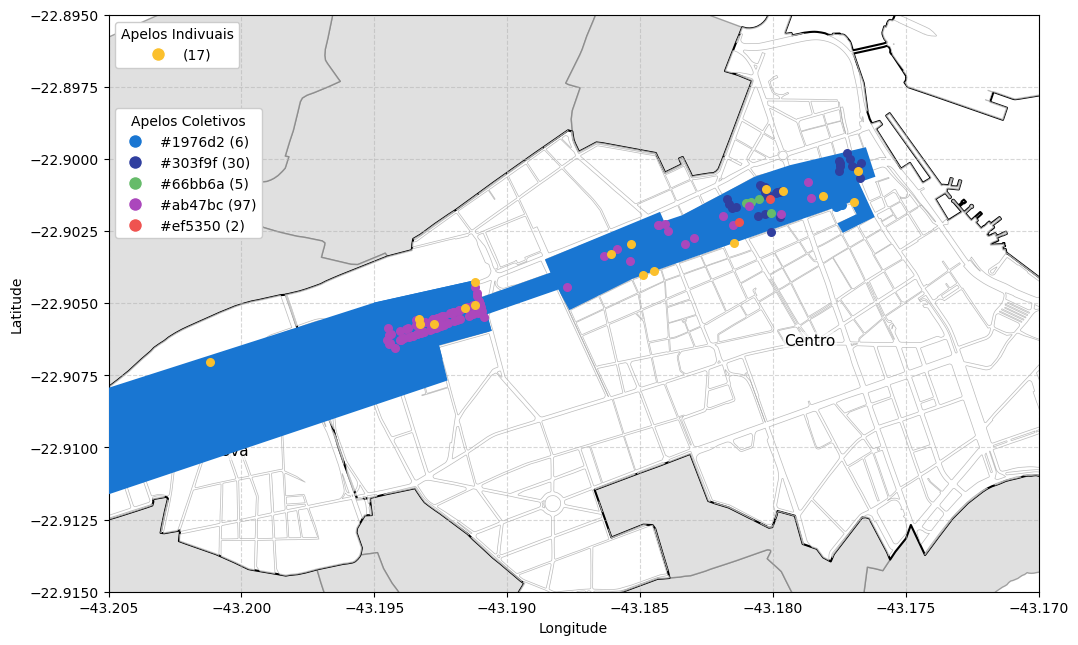

In [121]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a plot showing selected neighborhoods, surrounding neighborhoods, and apelos
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1. Plot surrounding neighborhoods in light gray
filtro_surrounding.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.7, label='Entorno')

# 2. Plot selected neighborhoods with a white background so they stand out
filtro_bairros.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, legend=True)

# 3. Plot the filtered blocks (quadras) in light gray
filtro_quadras.plot(ax=ax, color='white', edgecolor='darkgray', alpha=0.8, linewidth=0.5, label='Quadras')

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    ax.text(x, y, label, fontsize=11, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=4)

# ==========================================
# LEGEND SPLITTING LOGIC
# ==========================================
handles_yellow = []
labels_yellow = []

handles_others = []
labels_others = []

# REPLACE THIS WITH YOUR EXACT YELLOW HEX CODE (e.g., 'ffd966' or 'ffff00')
YELLOW_HEX = "fbc02d" 

# Plot apelos points, grouped by color
for color, group in apelos.groupby('Color'):
    count = len(group)
    
    # Plot the points directly on the axis
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', zorder=5)
    
    # Create a custom marker for the legend
    marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='#' + color, markersize=10)
    
    # Separate the yellow color from the rest
    if color.lower() == YELLOW_HEX.lower():
        handles_yellow.append(marker)
        labels_yellow.append(f'({count})')
    else:
        handles_others.append(marker)
        labels_others.append(f'#{color} ({count})')

# Customize the plot
# ax.set_title("Bairros Selecionados, Entorno, Quadras e Apelos", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ==========================================
# MANUALLY DEFINE X AND Y RANGE (LIMITS)
# ==========================================
# Replace these values with your desired bounding box coordinates
ax.set_xlim([-43.205, -43.170])  # [min_longitude, max_longitude]
ax.set_ylim([-22.915, -22.895])  # [min_latitude, max_latitude]

ax.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# DRAWING THE TWO LEGENDS
# ==========================================
# 1. Create the Yellow legend in the upper left
legend_yellow = ax.legend(handles_yellow, labels_yellow, title='Apelos Indivuais', 
                          loc='upper left', framealpha=1.0)
ax.add_artist(legend_yellow) # Attach it permanently to the plot

# 2. Create the Other Colors legend right below it
# (Using bbox_to_anchor to push it down so it doesn't overlap the first one)
legend_others = ax.legend(handles_others, labels_others, title='Apelos Coletivos', 
                          loc='upper left', bbox_to_anchor=(0, 0.85), framealpha=1.0)

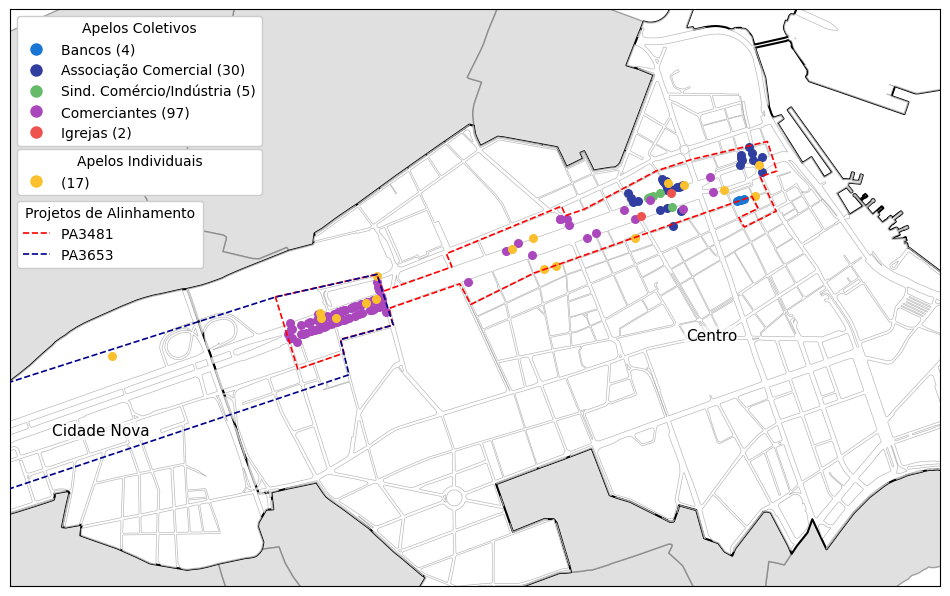

In [122]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a plot showing selected neighborhoods, surrounding neighborhoods, and apelos
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1. Plot surrounding neighborhoods in light gray
filtro_surrounding.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.7, label='Entorno')

# 2. Plot selected neighborhoods with a white background so they stand out
filtro_bairros.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, legend=True)

# 3. Plot the filtered blocks (quadras) in light gray
filtro_quadras.plot(ax=ax, color='white', edgecolor='darkgray', alpha=0.8, linewidth=0.5, label='Quadras')

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    # Adjust Y coordinate slightly upwards if the label is "Cidade Nova"
    if label == "Cidade Nova":
        y = y + 0.0005  
        
    ax.text(x, y, label, fontsize=11, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=4)

# ==========================================
# SEPARATE POINTS FROM POLYGONS/LINES
# ==========================================
# Geometries that are "Point" or "MultiPoint"
apelos_points = apelos[apelos.geometry.type.isin(['Point', 'MultiPoint'])]

# Geometries that are "Polygon", "LineString", or variations (your two polylines)
apelos_lines = apelos[~apelos.geometry.type.isin(['Point', 'MultiPoint'])]

# ==========================================
# LEGEND SPLITTING LOGIC (For Points)
# ==========================================
handles_yellow = []
labels_yellow = []

handles_others = []
labels_others = []

# REPLACE THIS WITH YOUR EXACT YELLOW HEX CODE (e.g., 'ffd966' or 'ffff00')
YELLOW_HEX = "fbc02d" 

# Dictionary mapping hex codes (in lowercase) to their new labels
COLOR_LABELS = {
    "ab47bc": "Comerciantes",
    "1976d2": "Bancos",
    "ef5350": "Igrejas",
    "66bb6a": "Sind. Comércio/Indústria",
    "303f9f": "Associação Comercial"
}

# Plot apelos points, grouped by color
for color, group in apelos_points.groupby('Color'):
    count = len(group)
    
    # Plot the points directly on the axis
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', zorder=5)
    
    # Create a custom marker for the legend
    marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='#' + color, markersize=10)
    
    color_lower = color.lower()
    
    # Separate the yellow color from the rest
    if color_lower == YELLOW_HEX.lower():
        handles_yellow.append(marker)
        # ----------------------------------------------------------------------
        # PADDING: Add lots of spaces to force the yellow box to stretch
        # Adjust the number of spaces if the box is slightly too big or too small
        # ----------------------------------------------------------------------
        labels_yellow.append(f'({count})                                      ')
    else:
        # Look up the custom label in the dictionary
        custom_name = COLOR_LABELS.get(color_lower, f'#{color}')
        
        handles_others.append(marker)
        labels_others.append(f'{custom_name} ({count})')

# ==========================================
# PLOT THE TWO POLYLINES & 3RD LEGEND LOGIC
# ==========================================
handles_lines = []
labels_lines = []

if not apelos_lines.empty:
    # Swapped colors: red first, then darkblue
    line_colors = ['red', 'darkblue']
    
    for idx, (index, row) in enumerate(apelos_lines.iterrows()):
        color = line_colors[idx % len(line_colors)]
        
        # Get name for the legend (PA3481, PA3653)
        line_name = row.get('Name', f'Linha {idx+1}')
        
        geo_row = apelos_lines.loc[[index]]
        
        # Plot thinner lines (linewidth=1.2 instead of 2.5)
        geo_row.plot(ax=ax, edgecolor=color, facecolor='none', 
                     linewidth=1.2, linestyle='--', zorder=6)
        
        # Add these lines to their own legend group
        line_marker = Line2D([0], [0], color=color, linestyle='--', linewidth=1.2)
        handles_lines.append(line_marker)
        # Pad the line legend as well so it matches the width
        labels_lines.append(f'{line_name}                   ')

# ==========================================
# MANUALLY DEFINE X AND Y RANGE (LIMITS)
# ==========================================
ax.set_xlim([-43.205, -43.170])  
ax.set_ylim([-22.915, -22.895])  

# ==========================================
# REMOVED GRID AND LABELS
# ==========================================
ax.set_xticks([])
ax.set_yticks([])

# ==========================================
# DRAWING THE THREE LEGENDS
# ==========================================
# 1. Create the Other Colors legend in the upper left
legend_others = ax.legend(handles_others, labels_others, title='Apelos Coletivos', 
                          loc='upper left', framealpha=1.0)
ax.add_artist(legend_others)

# 2. Create the Yellow legend right below it
# ----------------------------------------------------------------------
# PADDING: Add spaces to the title as well, otherwise the top of the 
# box will shrink and it won't align perfectly.
# ----------------------------------------------------------------------
legend_yellow = ax.legend(handles_yellow, labels_yellow, title='Apelos Individuais', 
                          loc='upper left', bbox_to_anchor=(0, 0.77), framealpha=1.0)
ax.add_artist(legend_yellow)

# 3. Create the Polylines legend below the second one
legend_lines = ax.legend(handles_lines, labels_lines, title='Projetos de Alinhamento', 
                         loc='upper left', bbox_to_anchor=(0, 0.68), framealpha=1.0)

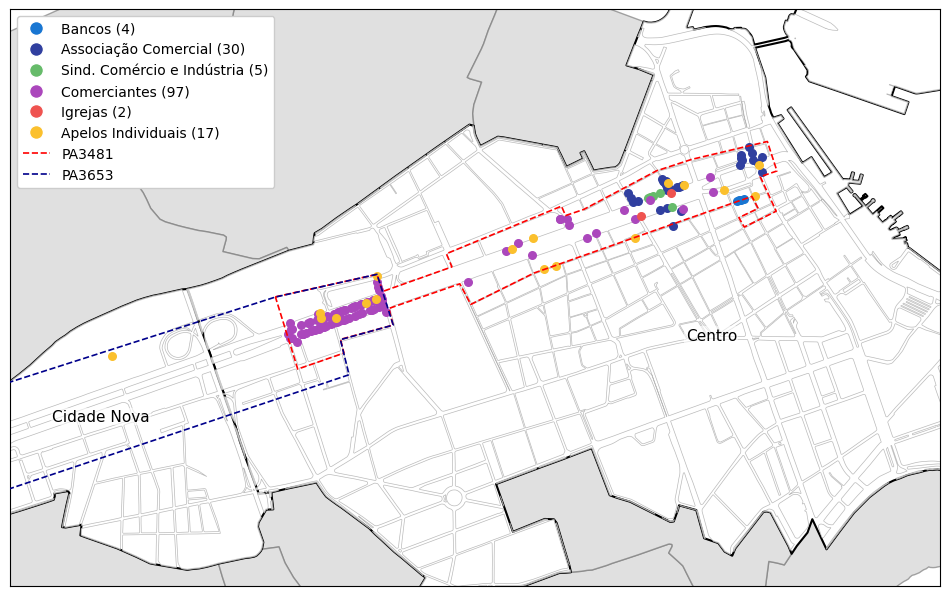

In [124]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a plot showing selected neighborhoods, surrounding neighborhoods, and apelos
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 1. Plot surrounding neighborhoods in light gray
filtro_surrounding.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.7, label='Entorno')

# 2. Plot selected neighborhoods with a white background so they stand out
filtro_bairros.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, legend=True)

# 3. Plot the filtered blocks (quadras) in light gray
filtro_quadras.plot(ax=ax, color='white', edgecolor='darkgray', alpha=0.8, linewidth=0.5, label='Quadras')

# Get accurate centroids using the new function
centroids = geo.get_centroids(filtro_bairros)

# Add labels for each selected neighborhood
for label, x, y in zip(filtro_bairros.nome, centroids.x, centroids.y):
    # Adjust Y coordinate slightly upwards if the label is "Cidade Nova"
    if label == "Cidade Nova":
        y = y + 0.001
        
    ax.text(x, y, label, fontsize=11, ha='center', va='center', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=4)

# ==========================================
# SEPARATE POINTS FROM POLYGONS/LINES
# ==========================================
# Geometries that are "Point" or "MultiPoint"
apelos_points = apelos[apelos.geometry.type.isin(['Point', 'MultiPoint'])]

# Geometries that are "Polygon", "LineString", or variations (your two polylines)
apelos_lines = apelos[~apelos.geometry.type.isin(['Point', 'MultiPoint'])]

# ==========================================
# UNIFIED LEGEND LOGIC (For Points)
# ==========================================
all_handles = []
all_labels = []

# REPLACE THIS WITH YOUR EXACT YELLOW HEX CODE (e.g., 'ffd966' or 'ffff00')
YELLOW_HEX = "fbc02d" 

# Dictionary mapping hex codes (in lowercase) to their new labels
COLOR_LABELS = {
    "ab47bc": "Comerciantes",
    "1976d2": "Bancos",
    "ef5350": "Igrejas",
    "66bb6a": "Sind. Comércio e Indústria",
    "303f9f": "Associação Comercial"
}

# Plot apelos points, grouped by color
for color, group in apelos_points.groupby('Color'):
    count = len(group)
    
    # Plot the points directly on the axis
    group.plot(ax=ax, color='#' + color, markersize=30, marker='o', zorder=5)
    
    # Create a custom marker for the legend
    marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='#' + color, markersize=10)
    
    color_lower = color.lower()
    
    # Check if it's the yellow color
    if color_lower == YELLOW_HEX.lower():
        all_handles.append(marker)
        # Give it the explicit name "Apelos Individuais"
        all_labels.append(f'Apelos Individuais ({count})')
    else:
        # Look up the custom label in the dictionary
        custom_name = COLOR_LABELS.get(color_lower, f'#{color}')
        
        all_handles.append(marker)
        all_labels.append(f'{custom_name} ({count})')

# ==========================================
# PLOT THE TWO POLYLINES & ADD TO UNIFIED LEGEND
# ==========================================
if not apelos_lines.empty:
    # Swapped colors: red first, then darkblue
    line_colors = ['red', 'darkblue']
    
    for idx, (index, row) in enumerate(apelos_lines.iterrows()):
        color = line_colors[idx % len(line_colors)]
        
        # Get name for the legend (PA3481, PA3653)
        line_name = row.get('Name', f'Linha {idx+1}')
        
        geo_row = apelos_lines.loc[[index]]
        
        # Plot thinner lines (linewidth=1.2 instead of 2.5)
        geo_row.plot(ax=ax, edgecolor=color, facecolor='none', 
                     linewidth=1.2, linestyle='--', zorder=6)
        
        # Add these lines to the main legend group
        line_marker = Line2D([0], [0], color=color, linestyle='--', linewidth=1.2)
        all_handles.append(line_marker)
        all_labels.append(line_name)

# ==========================================
# MANUALLY DEFINE X AND Y RANGE (LIMITS)
# ==========================================
ax.set_xlim([-43.205, -43.170])  
ax.set_ylim([-22.915, -22.895])  

# ==========================================
# REMOVED GRID AND LABELS
# ==========================================
ax.set_xticks([])
ax.set_yticks([])

# ==========================================
# DRAWING THE SINGLE UNIFIED LEGEND
# ==========================================
# Create one single legend with no title
# loc='upper left' places it nicely in the top-left corner
ax.legend(all_handles, all_labels, loc='upper left', framealpha=1.0)